In [1]:
# ==============================================================================
# CELL 1: IMPORTAÇÃO DOS DADOS DE ELITE
# ==============================================================================
import pandas as pd

caminho_treino = "./artefatos_ml/treino_selecionado.csv"
caminho_val = "./artefatos_ml/val_selecionado.csv"

print("1. Carregando os datasets isolados...")
df_treino = pd.read_csv(caminho_treino)
df_val = pd.read_csv(caminho_val)

print("2. Separando Features (X) e Alvo (y)...")
# Treino
X_train_final = df_treino.drop(columns=['label'])
y_train = df_treino['label']

# Validação
X_val_final = df_val.drop(columns=['label'])
y_val = df_val['label']

print(f"✅ Pronto para Modelagem! Features carregadas: {X_train_final.columns.tolist()}")

1. Carregando os datasets isolados...
2. Separando Features (X) e Alvo (y)...
✅ Pronto para Modelagem! Features carregadas: ['temp_entropy', 'ACI', 'NDSI', 'ratioBA', 'anthro_energy', 'mfcc_15', 'mfcc_17']


In [2]:
# ==============================================================================
# CELL 5: MODELING & TUNING (HOLD-OUT VALIDATION)
# ==============================================================================
import sys
from pathlib import Path

current_path = Path.cwd()
PROJECT_ROOT = None

for p in [current_path, current_path.parent, current_path.parent.parent]:
    if (p / "rainfall_acoustic_classification").exists():
        PROJECT_ROOT = p
        break

if PROJECT_ROOT:
    if str(PROJECT_ROOT) not in sys.path:
        sys.path.insert(0, str(PROJECT_ROOT)) # insert(0) garante prioridade absoluta
    print(f"✅ Raiz do projeto adicionada ao sys.path: {PROJECT_ROOT}")
else:
    print("❌ ERRO: Não foi possível encontrar a raiz do projeto.")

from rainfall_acoustic_classification.modeling import ClassifierFactory
from rainfall_acoustic_classification.modeling import TuningConfig, ModelOptimizer


✅ Raiz do projeto adicionada ao sys.path: /Users/fabiomachadomilan/Documents/GitHub/RAC-semiurban-forest-ML-2026


/Users/fabiomachadomilan/Documents/GitHub/RAC-semiurban-forest-ML-2026/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
print("1. Instanciando o algoritmo via Fábrica (Random Forest)...")
rf_base = ClassifierFactory.build(model_type='rf') 

print("2. Configurando a Grelha de Busca (GridSearch)...")
tuning_cfg = TuningConfig(
    param_grid={
        'n_estimators': [100, 200, 300], # Aumentei um pouco para estabilizar o RF
        'max_depth': [None, 10, 20],
        'class_weight': ['balanced', 'balanced_subsample'] # Vital para as poucas amostras de 'violent'
    },
    scoring_metric='f1_macro' # F1 Macro é a lei para dados desbalanceados
)

print("3. Iniciando Otimização (Holdout Set injeção direta)...")
# Otimizador treina com X_train_final e valida cegamente com X_val_final
modelo_campeao = ModelOptimizer.optimize(
    estimator=rf_base, 
    X_train=X_train_final, 
    y_train=y_train, 
    X_val=X_val_final, 
    y_val=y_val, 
    config=tuning_cfg
)

print("\n🏆 Modelo Campeão Encontrado!")

In [13]:
# ==============================================================================
# CELL 6: FINAL TEST EVALUATION (DRY/WET BINARY)
# ==============================================================================
import joblib
import pandas as pd
from rainfall_acoustic_classification.modeling import ModelEvaluator, ExperimentTracker
from rainfall_acoustic_classification.feature_engineering import ExperimentConfig, ExperimentCreator
df_test_raw = pd.read_csv("/Users/fabiomachadomilan/Documents/GitHub/RAC-semiurban-forest-ML-2026/data/processed/Chavascal/chavascal_test_metrics_patched.csv") 

tracker = ExperimentTracker()
# 1. Configuração do Experimento Binário (Dry/Wet)
mapa_binario_real = {
    'no-rain': 'Dry', 
    'light': 'Wet', 'moderate': 'Wet', 
    'heavy': 'Wet', 'violent': 'Wet'
}
exp_config_test = ExperimentConfig(content='dry/wet', granularity=2, custom_mapping=mapa_binario_real)

print("1. Carregando dados de TESTE brutos e aplicando mapeamento Dry/Wet...")
# Assumindo que df_test_raw foi carregado na Célula 1 do notebook
X_test_raw, y_test, meta_test = ExperimentCreator.apply_experiment_rules(
    *ExperimentCreator.extract_X_y_meta(df_test_raw, exp_config_test), exp_config_test
)

print("2. Carregando o Seletor de Features (O molde do Treino)...")
# Carregamos o pipeline que você salvou no final do Notebook 1
seletor_pipeline = joblib.load("./artefatos_ml/seletor_pipeline.pkl")

print("3. Transformando o Teste (Apenas .transform, sem fit!)...")
# Aqui o teste passa pelo SafeImputer, Scaler e Filtros que APRENDERAM com o treino
X_test_final = seletor_pipeline.transform(X_test_raw)

print("4. Executando Avaliação Final no Conjunto de Teste...")
# O teste de fogo: O modelo campeão contra dados 100% inéditos
resultados_test = ModelEvaluator.evaluate(modelo_campeao, X_test_final, y_test)

print("5. Registrando no Tracker (Versão Final de Publicação)...")
tracker.add_run(
    algorithm='Random Forest', 
    content='Dry/Wet',
    granularity='Binary', 
    domain='Chavascal (TESTE FINAL)', 
    evaluation_results=resultados_test
)

# Exibe o histórico para comparação
display(pd.DataFrame(tracker.records))

19:55:10 - [ExperimentTracker] - INFO - Experiment Tracker initialized. Clean slate.
1. Carregando dados de TESTE brutos e aplicando mapeamento Dry/Wet...
19:55:10 - [ExperimentCreator] - INFO - Applying Smart Rules -> Content: 'dry/wet' | Granularity: 2
2. Carregando o Seletor de Features (O molde do Treino)...
3. Transformando o Teste (Apenas .transform, sem fit!)...
4. Executando Avaliação Final no Conjunto de Teste...
19:55:11 - [ModelEvaluator] - INFO - Executing Rigorous Stress Test (Model Evaluation)...
19:55:11 - [ModelEvaluator] - INFO - Test Results -> F1-Macro: 0.9655 | PR-AUC: 0.9813175988940561
5. Registrando no Tracker (Versão Final de Publicação)...
19:55:11 - [ExperimentTracker] - INFO - Recorded Run -> [RANDOM FOREST | Dry/Wet | Binary | Chavascal (TESTE FINAL)]


,Algorithm,Content,Granularity,Domain,f1_macro,pr_auc_macro
0,RANDOM FOREST,Dry/Wet,Binary,Chavascal (TESTE FINAL),0.965492,0.981318


1. Gerando Matriz de Confusão Dupla (Absoluta e Normalizada)...
19:55:16 - [ModelingPlots] - INFO - Generating Dual Confusion Matrix Plot...


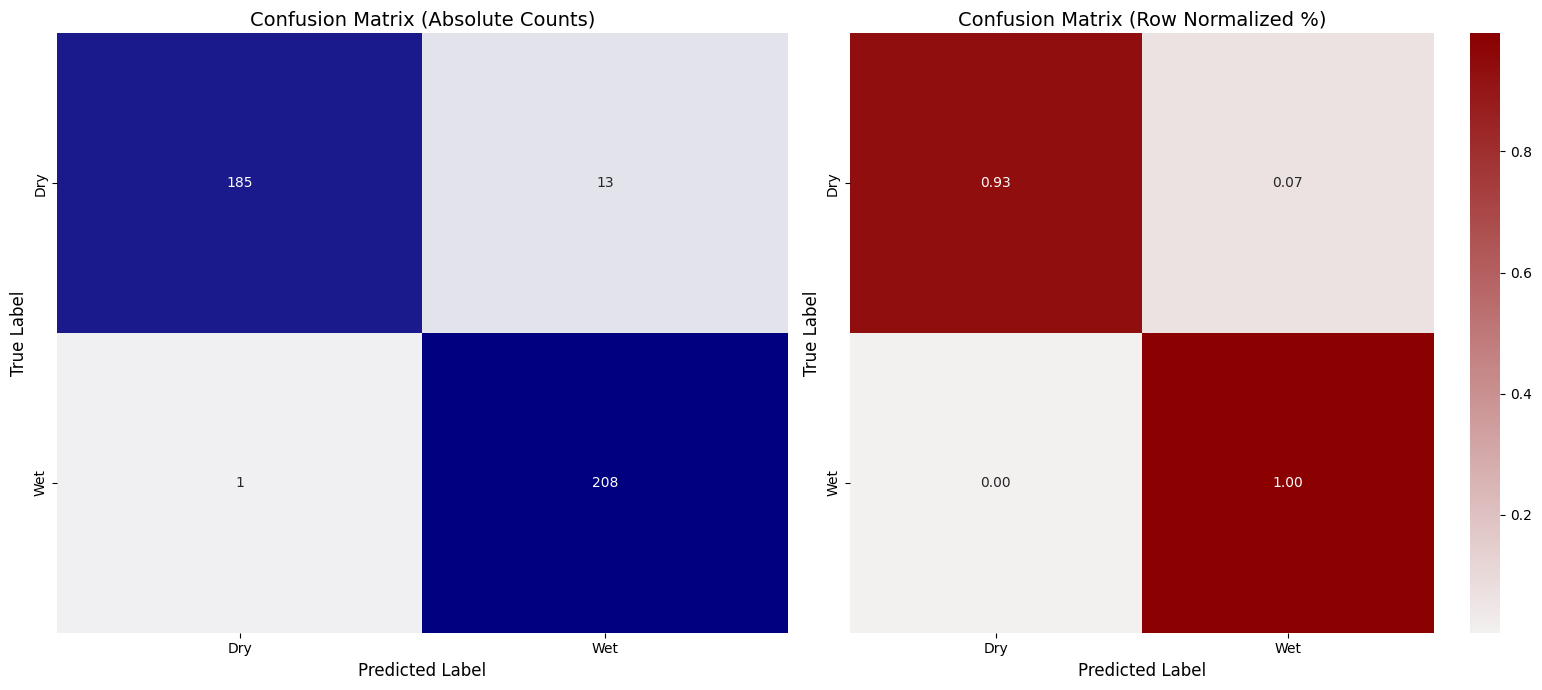

2. Gerando Curvas PR-AUC (Precision-Recall)...
19:55:17 - [ModelingPlots] - INFO - Generating Multiclass Precision-Recall Curves...


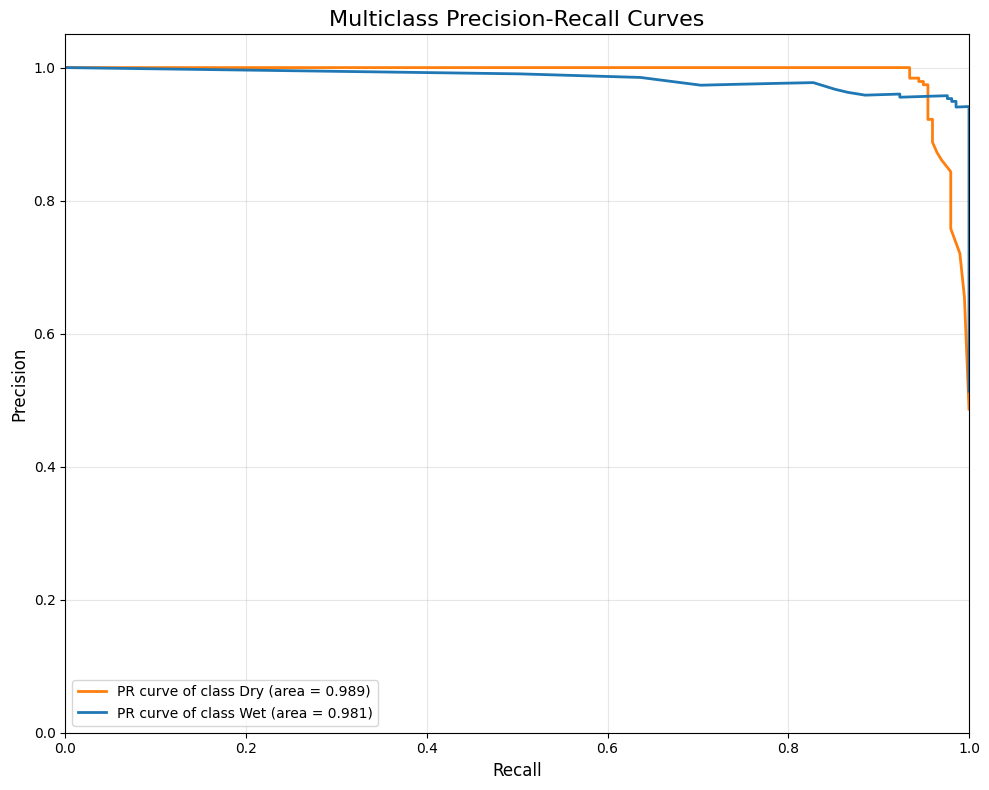

In [14]:
# ==============================================================================
# CELL 7: PUBLICATION PLOTS (EVALUATION)
# ==============================================================================
from rainfall_acoustic_classification.modeling.plots import (
    plot_confusion_matrix_grid, 
    plot_multiclass_pr_curve
)

print("1. Gerando Matriz de Confusão Dupla (Absoluta e Normalizada)...")
# Essa função vai mostrar onde o modelo está confundindo (Ex: Light vs Moderate)
plot_confusion_matrix_grid(
    cm_raw=resultados_test['confusion_matrix_raw'],
    cm_norm=resultados_test['confusion_matrix_normalized'],
    classes=resultados_test['classes']
)

print("2. Gerando Curvas PR-AUC (Precision-Recall)...")
# IMPORTANTE: Relembrando as cores exatas do seu projeto
cores_chuva = {
    'Wet': '#1f77b4',   # Azul claro
    'Dry': '#ff7f0e',# Laranja
}

# A Curva PR-AUC é a prova definitiva de que o modelo consegue achar a classe 
# 'violent' mesmo ela tendo apenas 4 ou 5 amostras no dataset de validação.
plot_multiclass_pr_curve(
    y_true=y_test,
    y_proba=resultados_test['y_proba'],
    color_map=cores_chuva,
    class_order=['Dry', 'Wet']
)

In [4]:
# ==============================================================================
# CELL 5: MULTI-MODEL TUNING (LR, XGB, SGD, RF)
# ==============================================================================
from rainfall_acoustic_classification.modeling import ClassifierFactory
from rainfall_acoustic_classification.modeling.tuning import TuningConfig, ModelOptimizer

# 1. Definição das Grelhas de Parâmetros para cada Algoritmo
# Ajustei os nomes dos parâmetros para o que o sklearn/xgboost geralmente esperam
configs_dos_modelos = {
    'rf': {
        'param_grid': {
            'n_estimators': [100, 200],
            'max_depth': [10, 20, None],
        }
    },
    'lr': {
        'param_grid': {
            'C': [0.1, 1.0, 10.0],
            'solver': ['lbfgs', 'liblinear'],
            'max_iter': [1000] # Garante convergência para dados acústicos
        }
    },
    'sgd': {
        'param_grid': {
            'alpha': [0.0001, 0.001, 0.01],
            'penalty': ['l2', 'elasticnet']
        }
    }
}

# ESCOLHA AQUI O MODELO: 'rf', 'lr', 'sgd'
modelo_alvo = 'sgd' 

print(f"🚀 Iniciando Experimento com: {modelo_alvo.upper()}")

# 2. Instancia o algoritmo escolhido
model_base = ClassifierFactory.build(model_type=modelo_alvo) 

# 3. Configura a TuningConfig dinamicamente
tuning_cfg = TuningConfig(
    param_grid=configs_dos_modelos[modelo_alvo]['param_grid'],
    scoring_metric='f1_macro'
)

# 4. Executa a otimização
print(f"3. Otimizando hiperparâmetros para {modelo_alvo}...")
modelo_campeao = ModelOptimizer.optimize(
    estimator=model_base, 
    X_train=X_train_final, 
    y_train=y_train, 
    X_val=X_val_final, 
    y_val=y_val, 
    config=tuning_cfg
)

print(f"\n🏆 Modelo {modelo_alvo.upper()} Campeão Encontrado!")
print(f"Melhores parâmetros: {modelo_campeao.get_params()}")

🚀 Iniciando Experimento com: SGD
21:08:11 - [ClassifierFactory] - INFO - CPU Scaling: Requested -1 -> Allocated 3 cores.
21:08:11 - [ClassifierFactory] - INFO - Building registered model architecture: SGD
3. Otimizando hiperparâmetros para sgd...
21:08:11 - [HyperparameterTuner] - INFO - Starting Optimization Engine. Target Metric: f1_macro
Fitting 1 folds for each of 6 candidates, totalling 6 fits
21:08:18 - [HyperparameterTuner] - INFO - Optimization complete. Champion Score (f1_macro) on Val Set: 0.9902
21:08:18 - [HyperparameterTuner] - INFO - Champion Hyperparameters: {'alpha': 0.0001, 'penalty': 'l2'}
21:08:18 - [HyperparameterTuner] - INFO - Refitting the champion model exclusively on the Training Set...

🏆 Modelo SGD Campeão Encontrado!
Melhores parâmetros: {'alpha': 0.0001, 'average': False, 'class_weight': 'balanced', 'early_stopping': False, 'epsilon': 0.1, 'eta0': 0.0, 'fit_intercept': True, 'l1_ratio': 0.15, 'learning_rate': 'optimal', 'loss': 'log_loss', 'max_iter': 1000,

In [17]:
# ==============================================================================
# CELL 6: FINAL TEST EVALUATION (DRY/WET BINARY)
# ==============================================================================
import joblib
import pandas as pd
from rainfall_acoustic_classification.modeling import ModelEvaluator, ExperimentTracker
from rainfall_acoustic_classification.feature_engineering import ExperimentConfig, ExperimentCreator
df_test_raw = pd.read_csv("/Users/fabiomachadomilan/Documents/GitHub/RAC-semiurban-forest-ML-2026/data/processed/Chavascal/chavascal_test_metrics_patched.csv") 

tracker = ExperimentTracker()
# 1. Configuração do Experimento Binário (Dry/Wet)
mapa_binario_real = {
    'no-rain': 'Dry', 
    'light': 'Wet', 'moderate': 'Wet', 
    'heavy': 'Wet', 'violent': 'Wet'
}
exp_config_test = ExperimentConfig(content='dry/wet', granularity=2, custom_mapping=mapa_binario_real)

print("1. Carregando dados de TESTE brutos e aplicando mapeamento Dry/Wet...")
# Assumindo que df_test_raw foi carregado na Célula 1 do notebook
X_test_raw, y_test, meta_test = ExperimentCreator.apply_experiment_rules(
    *ExperimentCreator.extract_X_y_meta(df_test_raw, exp_config_test), exp_config_test
)

print("2. Carregando o Seletor de Features (O molde do Treino)...")
# Carregamos o pipeline que você salvou no final do Notebook 1
seletor_pipeline = joblib.load("./artefatos_ml/seletor_pipeline.pkl")

print("3. Transformando o Teste (Apenas .transform, sem fit!)...")
# Aqui o teste passa pelo SafeImputer, Scaler e Filtros que APRENDERAM com o treino
X_test_final = seletor_pipeline.transform(X_test_raw)

print("4. Executando Avaliação Final no Conjunto de Teste...")
# O teste de fogo: O modelo campeão contra dados 100% inéditos
resultados_test = ModelEvaluator.evaluate(modelo_campeao, X_test_final, y_test)

print("5. Registrando no Tracker (Versão Final de Publicação)...")
tracker.add_run(
    algorithm='Logistic Regression', 
    content='Dry/Wet',
    granularity='Binary', 
    domain='Chavascal (TESTE FINAL)', 
    evaluation_results=resultados_test
)

# Exibe o histórico para comparação
display(pd.DataFrame(tracker.records))

20:03:29 - [ExperimentTracker] - INFO - Experiment Tracker initialized. Clean slate.
1. Carregando dados de TESTE brutos e aplicando mapeamento Dry/Wet...
20:03:29 - [ExperimentCreator] - INFO - Applying Smart Rules -> Content: 'dry/wet' | Granularity: 2
2. Carregando o Seletor de Features (O molde do Treino)...
3. Transformando o Teste (Apenas .transform, sem fit!)...
4. Executando Avaliação Final no Conjunto de Teste...
20:03:30 - [ModelEvaluator] - INFO - Executing Rigorous Stress Test (Model Evaluation)...
20:03:30 - [ModelEvaluator] - INFO - Test Results -> F1-Macro: 0.9311 | PR-AUC: 0.9763994138090631
5. Registrando no Tracker (Versão Final de Publicação)...
20:03:30 - [ExperimentTracker] - INFO - Recorded Run -> [LOGISTIC REGRESSION | Dry/Wet | Binary | Chavascal (TESTE FINAL)]


,Algorithm,Content,Granularity,Domain,f1_macro,pr_auc_macro
0,LOGISTIC REGRESSION,Dry/Wet,Binary,Chavascal (TESTE FINAL),0.93111,0.976399


In [24]:
# ==============================================================================
# CELL 6: FINAL TEST EVALUATION (DRY/WET BINARY)
# ==============================================================================
import joblib
import pandas as pd
from rainfall_acoustic_classification.modeling import ModelEvaluator, ExperimentTracker
from rainfall_acoustic_classification.feature_engineering import ExperimentConfig, ExperimentCreator
df_test_raw = pd.read_csv("/Users/fabiomachadomilan/Documents/GitHub/RAC-semiurban-forest-ML-2026/data/processed/Chavascal/chavascal_test_metrics_patched.csv") 

tracker = ExperimentTracker()
# 1. Configuração do Experimento Binário (Dry/Wet)
mapa_binario_real = {
    'no-rain': 'Dry', 
    'light': 'Wet', 'moderate': 'Wet', 
    'heavy': 'Wet', 'violent': 'Wet'
}
exp_config_test = ExperimentConfig(content='dry/wet', granularity=2, custom_mapping=mapa_binario_real)

print("1. Carregando dados de TESTE brutos e aplicando mapeamento Dry/Wet...")
# Assumindo que df_test_raw foi carregado na Célula 1 do notebook
X_test_raw, y_test, meta_test = ExperimentCreator.apply_experiment_rules(
    *ExperimentCreator.extract_X_y_meta(df_test_raw, exp_config_test), exp_config_test
)

print("2. Carregando o Seletor de Features (O molde do Treino)...")
# Carregamos o pipeline que você salvou no final do Notebook 1
seletor_pipeline = joblib.load("./artefatos_ml/seletor_pipeline.pkl")

print("3. Transformando o Teste (Apenas .transform, sem fit!)...")
# Aqui o teste passa pelo SafeImputer, Scaler e Filtros que APRENDERAM com o treino
X_test_final = seletor_pipeline.transform(X_test_raw)

print("4. Executando Avaliação Final no Conjunto de Teste...")
# O teste de fogo: O modelo campeão contra dados 100% inéditos
resultados_test = ModelEvaluator.evaluate(modelo_campeao, X_test_final, y_test)

print("5. Registrando no Tracker (Versão Final de Publicação)...")
tracker.add_run(
    algorithm='SGD', 
    content='Dry/Wet',
    granularity='Binary', 
    domain='Chavascal (TESTE FINAL)', 
    evaluation_results=resultados_test
)

# Exibe o histórico para comparação
display(pd.DataFrame(tracker.records))

20:06:16 - [ExperimentTracker] - INFO - Experiment Tracker initialized. Clean slate.
1. Carregando dados de TESTE brutos e aplicando mapeamento Dry/Wet...
20:06:16 - [ExperimentCreator] - INFO - Applying Smart Rules -> Content: 'dry/wet' | Granularity: 2
2. Carregando o Seletor de Features (O molde do Treino)...
3. Transformando o Teste (Apenas .transform, sem fit!)...
4. Executando Avaliação Final no Conjunto de Teste...
20:06:16 - [ModelEvaluator] - INFO - Executing Rigorous Stress Test (Model Evaluation)...
20:06:16 - [ModelEvaluator] - INFO - Test Results -> F1-Macro: 0.9507 | PR-AUC: 0.9770645915714314
5. Registrando no Tracker (Versão Final de Publicação)...
20:06:16 - [ExperimentTracker] - INFO - Recorded Run -> [SGD | Dry/Wet | Binary | Chavascal (TESTE FINAL)]


,Algorithm,Content,Granularity,Domain,f1_macro,pr_auc_macro
0,SGD,Dry/Wet,Binary,Chavascal (TESTE FINAL),0.950703,0.977065
